## Navigo GRN Analysis: Congenital Heart Disease

In [1]:
import anndata, warnings, torch
import matplotlib.pyplot as plt, numpy as np, pandas as pd, seaborn as sns
from pathlib import Path
from scipy.optimize import linear_sum_assignment
import navigo, navigo.tl, navigo.pl, navigo.grn
from navigo.network import collect_edges, plot_three_layer_network
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Configuration

In [2]:
DATA_DIR       = Path("/scratch/users/steorra/analysis/26_yimin/data")
CHECKPOINT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/checkpoints")
OUTPUT_DIR     = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")
data_root = DATA_DIR / 'grn'; shared_data_root = DATA_DIR / 'shared'
DATA_PATH       = shared_data_root / 'mouse_heart_fibroblasts.h5ad'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'grn' / 'grn_checkpoint_heart.pth'
GENE_CLASS_PATH = data_root / 'gene_classification_summary.csv'
MSIGDB_PATH     = data_root / 'msigdb_mouse_v2025_1.json'
DYNAMO_JAC_PATH = data_root / 'jacobian_dynamo.csv'
TF_LIST_PATH    = data_root / 'mouse_tf_list_in_data.csv'
DEG_PATH        = data_root / 'atrial_vs_ventricular_deg.csv'
CELL_TYPE = 'First heart field'; CELL_TYPE_TAG = 'First_heart_field'
KO_MULTIPLIER = 0.0; DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT_ROOT = OUTPUT_DIR / 'grn_chd_analysis'
RAW_OUT = OUT_ROOT / 'inference_raw'; RESULT_TABLE_DIR = OUT_ROOT / 'results'
TMP_DIR = OUT_ROOT / 'tmp'; FIG_DIR = OUT_ROOT / 'figures'
for d in [OUT_ROOT, RAW_OUT, RESULT_TABLE_DIR, TMP_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)
navigo.set_seed(0)

## Step 1: Prepare data — subset to first heart field

In [3]:
adata = anndata.read_h5ad(DATA_PATH)
if 'gene_name' not in adata.var.columns:
    adata.var['gene_name'] = adata.var.get('gene_short_name', adata.var_names).astype(str)
adata_subset = adata[adata.obs['cell_type'].astype(str) == CELL_TYPE].copy()
adata_subset.obs['cell_type'] = 'SelectedCells'
print(f'Subset: {adata_subset.shape}')

Subset: (4303, 3902)


## Step 2: Extract CHD target gene list

In [4]:
cls_df = pd.read_csv(GENE_CLASS_PATH)
targets = cls_df['Gene'].astype(str).str.strip().dropna().unique().tolist()
subset_path = TMP_DIR / 'subset.h5ad'; adata_subset.write_h5ad(subset_path)
target_path = TMP_DIR / 'targets.txt'; target_path.write_text('\n'.join(targets) + '\n')
print(f'CHD targets: {len(targets)}')

CHD targets: 58


## Step 3: Run perturbation inference

In [5]:
if not list(RESULT_TABLE_DIR.glob('*_neg0.0x_knockout_First_heart_field.csv')):
    navigo.run_perturbation_inference(
        data_path=subset_path, checkpoint_path=CHECKPOINT_PATH,
        target_list_path=target_path, output_dir=RAW_OUT,
        fibro_cell_type='SelectedCells', input_dim=int(adata_subset.n_vars*2),
        hidden_1=5012, hidden_2=5012, flow_num_steps=100, simulation_steps=10,
        knockout_scale=KO_MULTIPLIER, device=DEVICE, strict_target_presence=False,
    )
print(f"Raw CSVs: {len(list(RAW_OUT.glob('*.csv')))}")

Raw CSVs: 58


## Step 4: Compute wild-type expression and relative change

In [6]:
if not list(RESULT_TABLE_DIR.glob('*_neg0.0x_knockout_First_heart_field.csv')):
    navigo.tl.compute_grn_expression_changes(
        adata_subset, CHECKPOINT_PATH, RAW_OUT, RESULT_TABLE_DIR, CELL_TYPE_TAG,
        ko_multiplier=KO_MULTIPLIER, device=DEVICE, simulation_steps=10,
    )
print(f"Result CSVs: {len(list(RESULT_TABLE_DIR.glob('*.csv')))}")

Result CSVs: 58


## Step 5: Cluster response vectors (PCA + KMeans + UMAP)

In [7]:
result = navigo.grn.cluster_and_embed(
    RESULT_TABLE_DIR, n_clusters=4, msigdb_path=MSIGDB_PATH,
)
embed_df = result['embed']
print(f"Clustered {len(embed_df)} genes into {embed_df['cluster'].nunique()} clusters")

Clustered 58 genes into 4 clusters


## Step 6: Response-vector UMAP

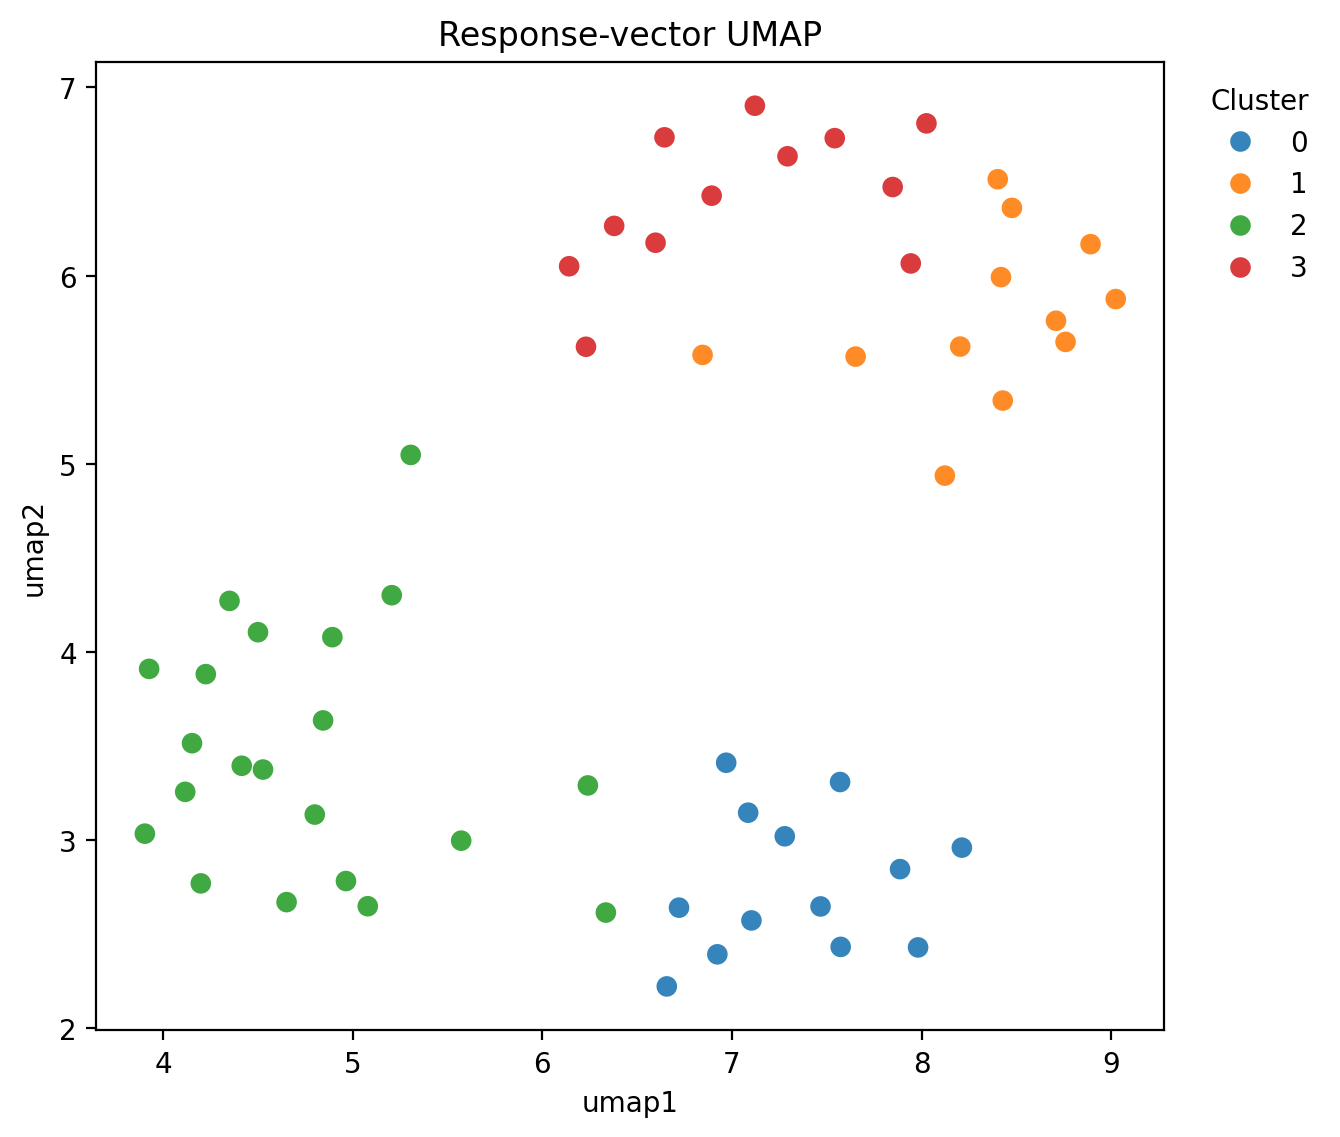

In [8]:
fig, ax = plt.subplots(figsize=(6.8, 5.8))
sns.scatterplot(data=embed_df, x='umap1', y='umap2', hue='cluster', palette='tab10',
                s=55, alpha=0.9, edgecolor='none', ax=ax)
ax.set_title('Response-vector UMAP')
ax.legend(title='Cluster', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

## Step 7: Distance to cluster centroids

<Axes: title={'center': 'CHD Genes: Distance to Cluster Centroids'}>

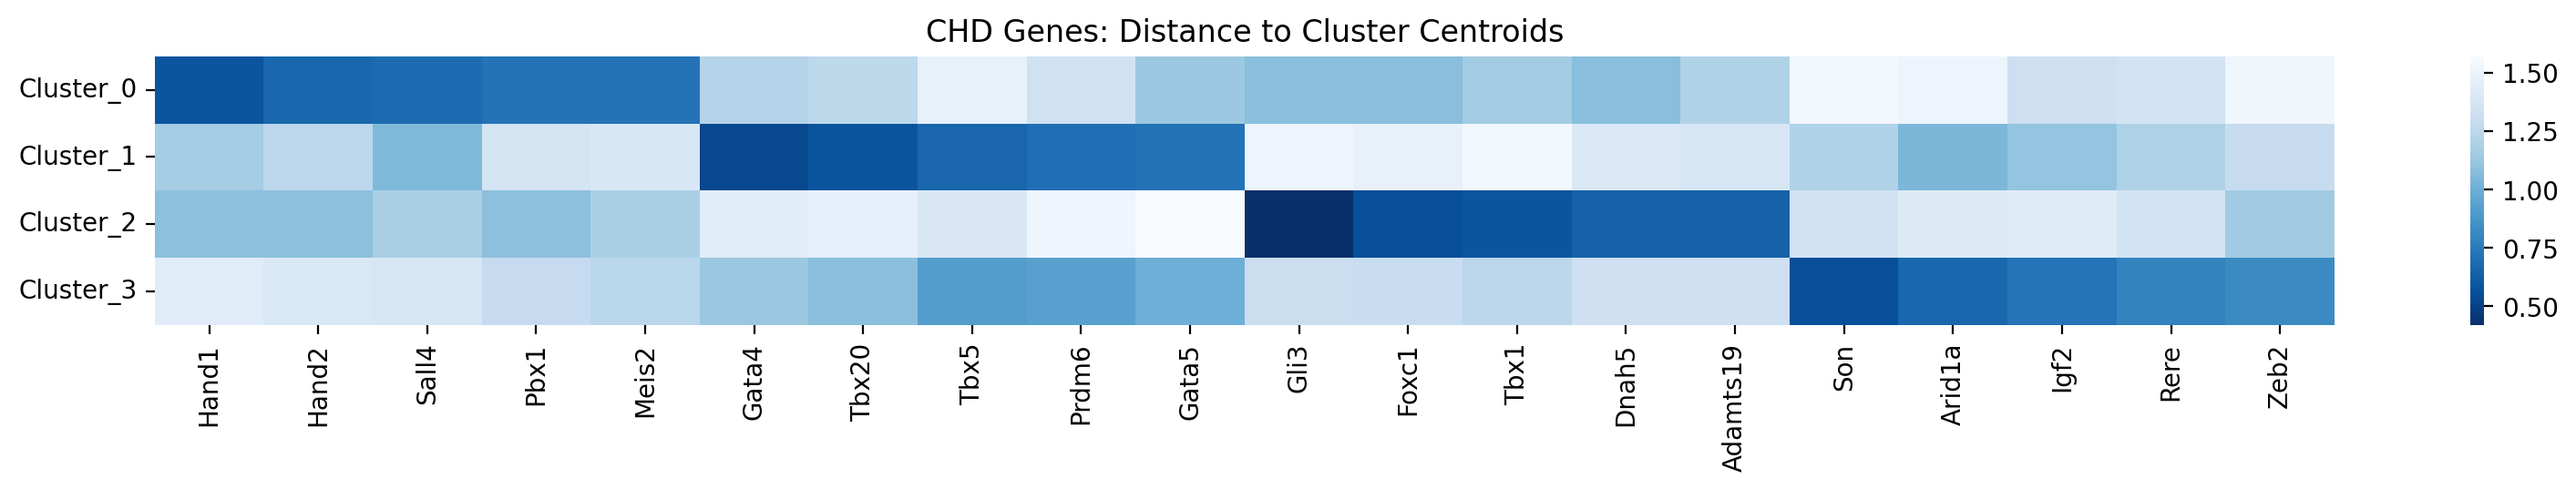

In [9]:
dist_hm = navigo.grn.top_genes_distance_matrix(result['distances'])
navigo.pl.expression_heatmap(dist_hm, title='CHD Genes: Distance to Cluster Centroids', cmap='Blues_r')

## Step 8: CHD cluster distribution

In [10]:
cls_indexed = pd.read_csv(GENE_CLASS_PATH, index_col=0)
chd_dist = navigo.grn.chd_cluster_distribution(result['gene_clusters'], cls_indexed)

### Align cluster labels with reference

<Axes: title={'center': 'CHD cluster distribution'}>

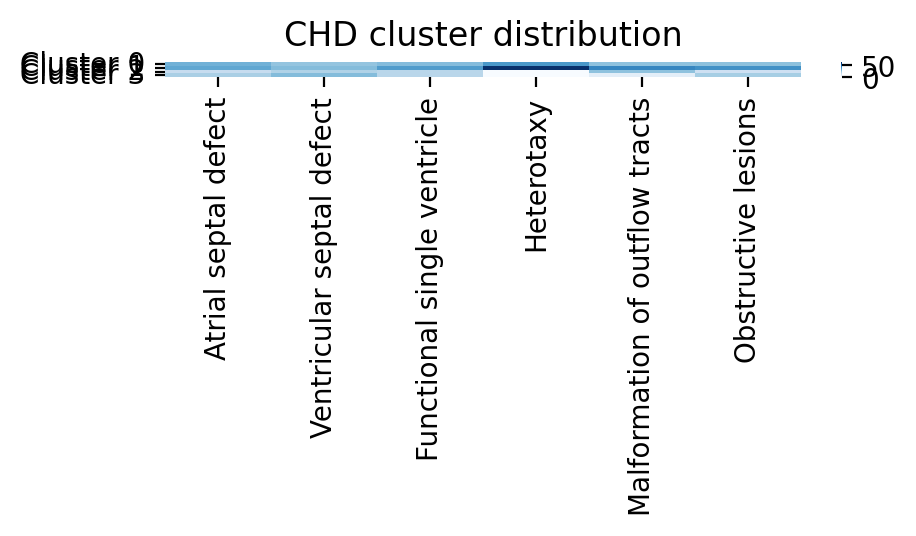

In [11]:
ref_gc = pd.read_csv(data_root / 'reference' / 'gene_clusters.csv')
mm = result['gene_clusters'].merge(ref_gc, on='gene', suffixes=('_new', '_ref'))
cont = pd.crosstab(mm['cluster_new'], mm['cluster_ref']).reindex(index=range(4), columns=range(4), fill_value=0)
rr, cc = linear_sum_assignment(-cont.values)
c_map = {int(r): int(c) for r, c in zip(rr, cc)}

plot_df = chd_dist.rename(columns=c_map).reindex(columns=[0,1,2,3]).T
labels = {'ASD':'Atrial septal defect','VSD':'Ventricular septal defect',
          'Functional single ventricle':'Functional single ventricle','Heterotaxy':'Heterotaxy',
          'Malformation of outflow tracts':'Malformation of outflow tracts','Obstructive lesions':'Obstructive lesions'}
plot_df = plot_df[list(labels)]; plot_df.columns = list(labels.values())
plot_df.index = [f'Cluster {i}' for i in plot_df.index]
navigo.pl.expression_heatmap(plot_df, title='CHD cluster distribution', cmap='Blues')

## Step 9: Pathway enrichment — outflow tract malformations

<Axes: title={'center': 'Outflow tract pathway enrichment'}, xlabel='$-\\log_{10}$(p-value)'>

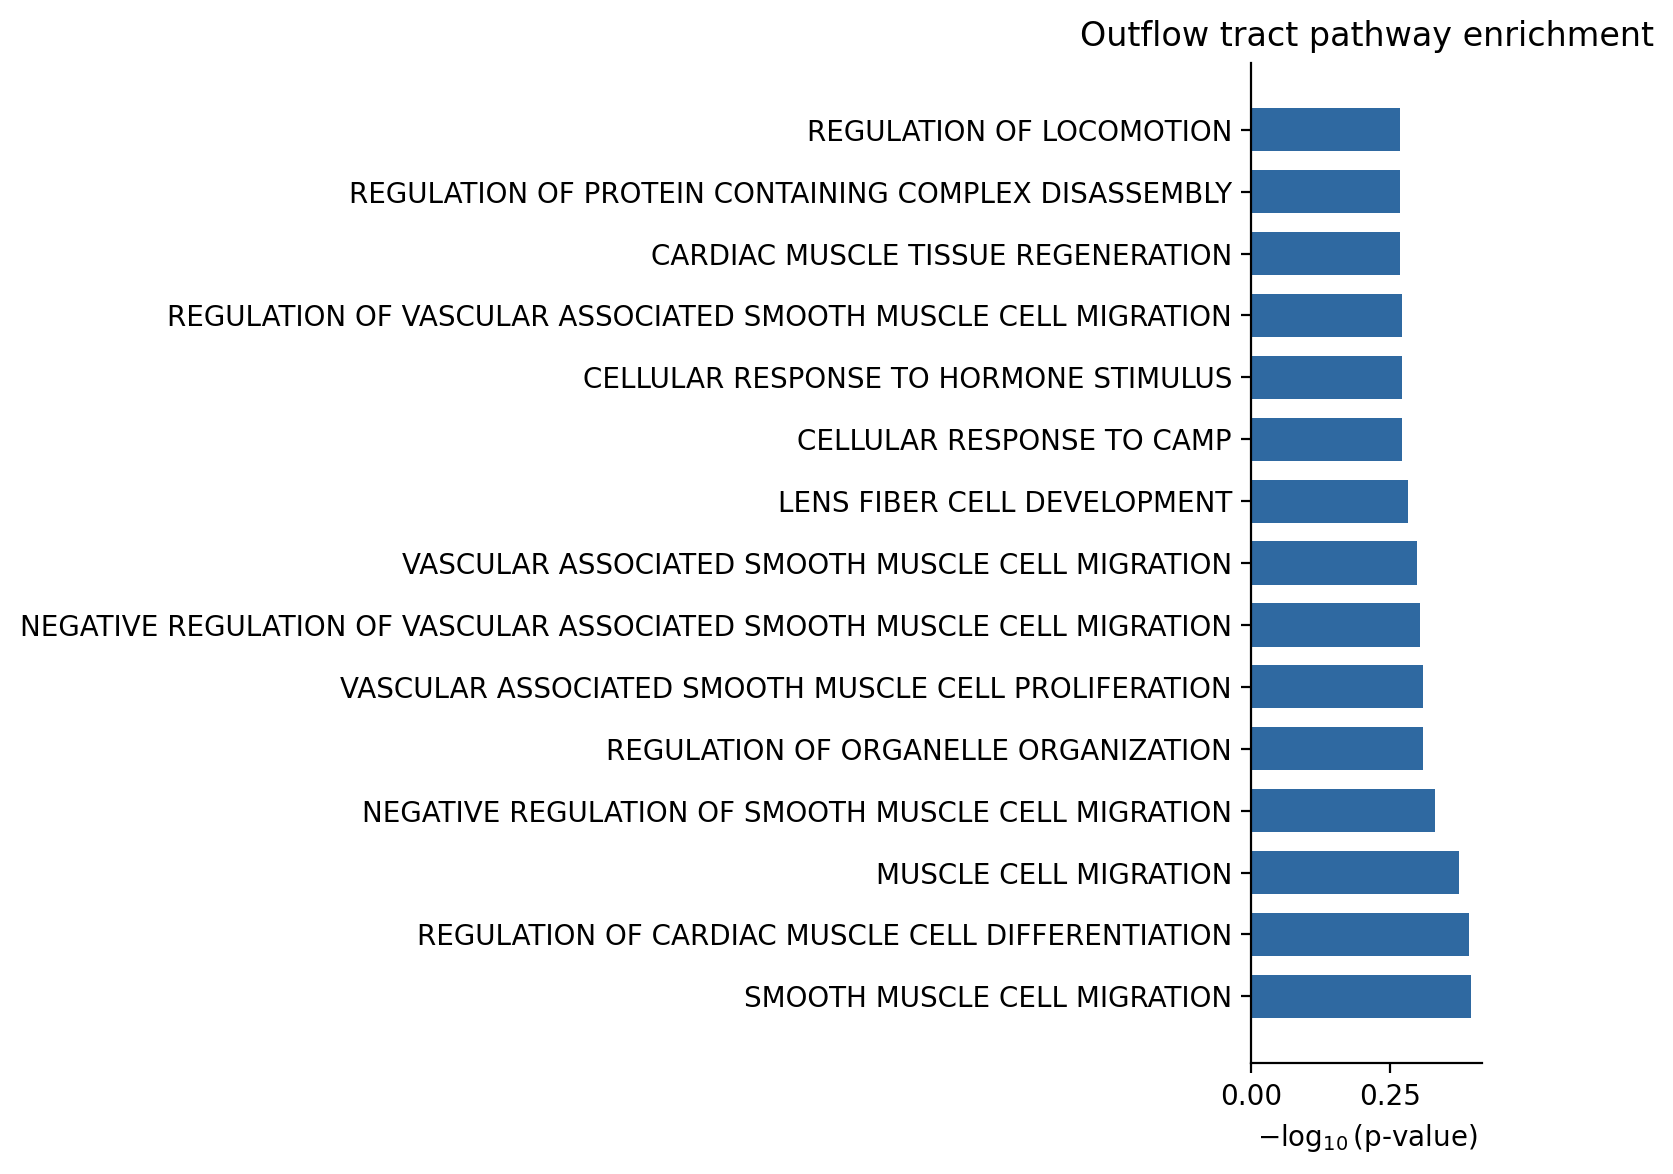

In [12]:
ot_df = navigo.grn.pathway_enrichment_comparison(
    RESULT_TABLE_DIR, cls_indexed, MSIGDB_PATH, term='Malformation of outflow tracts',
)
ot_top = ot_df.head(15).iloc[::-1]
navigo.pl.enrichment_barh(ot_top['pathway'], ot_top['ratio_diff'],
                          title='Outflow tract pathway enrichment', significance_line=None)

## Step 10: Load DEG markers (atrial vs ventricular)

In [13]:
deg_df = pd.read_csv(DEG_PATH, index_col=0)
tf_genes = set(pd.read_csv(TF_LIST_PATH).iloc[:, 0])

## Step 11: Marker ratio analysis — Navigo

<Axes: title={'left': 'Navigo'}, ylabel='Impact ratio'>

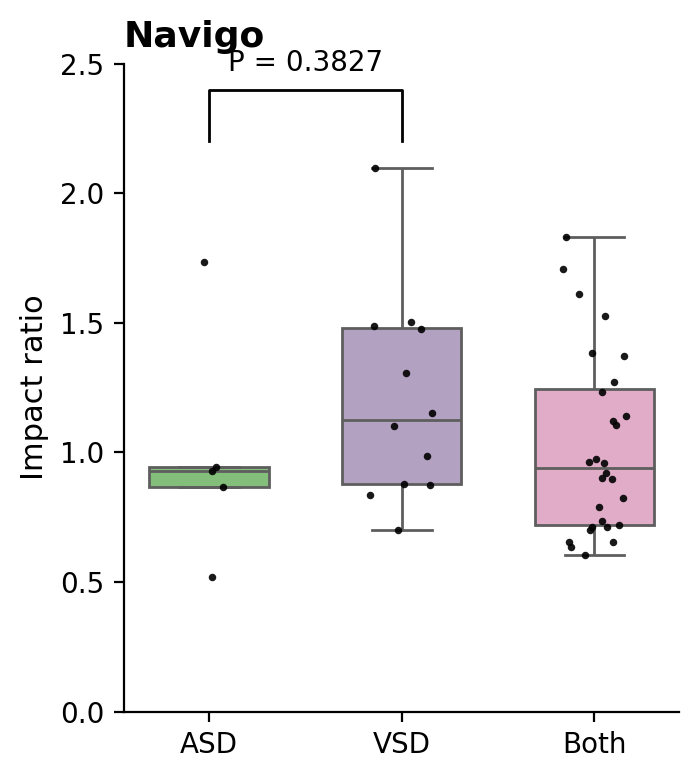

In [14]:
navigo_markers = navigo.grn.marker_change_analysis(
    RESULT_TABLE_DIR, deg_df, cls_df, tf_genes=tf_genes,
)
nav_plot = navigo_markers[navigo_markers['type'].isin(['ASD_only','VSD_only','Both'])].copy()
nav_plot['type'] = nav_plot['type'].map({'ASD_only':'ASD','VSD_only':'VSD','Both':'Both'})
navigo.pl.marker_ratio_boxplot(nav_plot, 'type', 'marker_v_to_a_ratio',
    groups=['ASD','VSD','Both'], palette={'ASD':'#7BC96F','VSD':'#B39BC8','Both':'#E9A3C9'},
    title='Navigo', ylim_max=2.5, stat_pair=('ASD','VSD'))

## Step 12: Marker ratio analysis — Dynamo (Jacobian baseline)

<Axes: title={'left': 'Dynamo'}, ylabel='Impact ratio'>

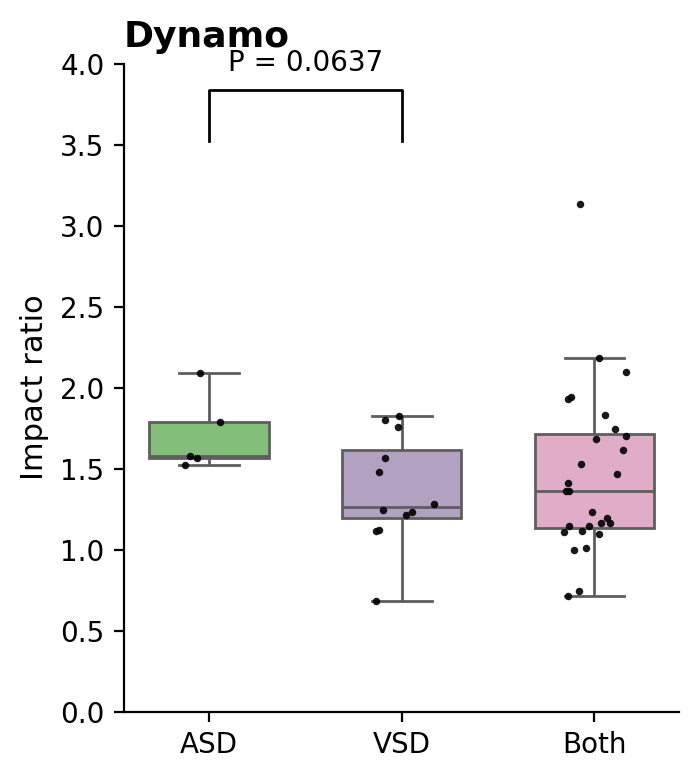

In [15]:
jac_df = pd.read_csv(DYNAMO_JAC_PATH, index_col=0)
dynamo_markers = navigo.grn.marker_change_from_jacobian(
    jac_df, deg_df, cls_df, tf_genes=tf_genes,
)
dyn_plot = dynamo_markers[dynamo_markers['type'].isin(['ASD_only','VSD_only','Both'])].copy()
dyn_plot['type'] = dyn_plot['type'].map({'ASD_only':'ASD','VSD_only':'VSD','Both':'Both'})
navigo.pl.marker_ratio_boxplot(dyn_plot, 'type', 'marker_v_to_a_ratio',
    groups=['ASD','VSD','Both'], palette={'ASD':'#7BC96F','VSD':'#B39BC8','Both':'#E9A3C9'},
    title='Dynamo', ylim_max=4.0, stat_pair=('ASD','VSD'))